# Forecasting stock prices with `hyp.predict`

Stock forecasting is the classic playground for timeseries models -- and the
classic cautionary tale. In this tutorial we'll:

1. Download **real** daily closing prices for a handful of stocks with
   `hyp.load('yahoo:<TICKER>', start=..., end=...)`.
2. Fit several `hyp.predict` models (`'Kalman'`, `'ARIMA'`, `'Laplace'`,
   `'GaussianProcess'`, `'AutoRegressor'`, and the pretrained `'Chronos'`
   foundation model) on all but the last 30 trading days.
3. Backtest those last 30 days with `hyp.predict(..., holdout=HOLD)` and
   score the forecasts against what *actually* happened, using mean
   absolute error (MAE) and mean absolute percentage error (MAPE) --
   alongside a naive "tomorrow = today" baseline `hyp.predict` reports
   automatically.
4. Visualize the forecasts, both in HyperTools' reduced plotting space and
   directly in price space.
5. Demonstrate `return_model=True`: fit once, reuse the fitted forecaster
   on a stock it has never seen.

A word of honesty up front: daily equity closing prices are close to a
random walk. Under the efficient-market hypothesis, the best predictor of
tomorrow's price is roughly today's price, and no simple timeseries model
should be expected to reliably beat that. The point of this tutorial is
**not** to hand you a money machine -- it's to demonstrate the `hyp.predict`
API and an honest evaluation methodology. We report whatever numbers come
out below, including if (when) the naive baseline wins.

In [ ]:
import importlib.util

if importlib.util.find_spec('hypertools') is None:
    # On Colab (or any fresh environment), install hypertools. Every
    # forecasting model used below either ships with the core install
    # (pykalman, statsmodels) or installs itself on first use (skaters for
    # 'Laplace', chronos-forecasting for 'Chronos'). hyp.load('yahoo:...')
    # uses `requests`, which ships with hypertools's core install -- no
    # separate yfinance install is needed.
    %pip install -q "hypertools[interactive]"

## Downloading real price data

We'll grab about two years of daily adjusted closes for four large, liquid,
very different stocks: Apple (`AAPL`), Microsoft (`MSFT`), Nvidia (`NVDA`),
and JPMorgan (`JPM`), via `hyp.load('yahoo:<TICKER>', start=..., end=...)`.

We work in **log prices** rather than raw dollar prices for two standard
reasons: (1) daily log-price differences are approximately the daily
percentage return, so a model that is well-behaved in log space corresponds
to sensible multiplicative (percentage) behavior in price space, and (2)
forecasting models that assume roughly constant noise variance (Kalman,
ARIMA, GaussianProcess) fit much more naturally to log prices than to raw
prices, whose absolute volatility grows with the price level. We convert
forecasts back to dollar prices (via `exp`) for the price-space plots later
in this tutorial; the honest backtest below scores directly in log-price
space, where every model is fit.

If the live `hyp.load('yahoo:...')` download is unavailable (offline,
rate-limited, or the API is having a bad day), the notebook falls back to a
real-data snapshot (`stock_closes_cached.csv` / `stock_volumes_cached.csv`)
shipped alongside this notebook, and prints a notice -- so the tutorial
always runs on real market data.

In [1]:
%matplotlib inline
import time

import numpy as np
import pandas as pd

import hypertools as hyp

tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM']
CACHE = {'close': 'stock_closes_cached.csv',
         'volume': 'stock_volumes_cached.csv'}


def fetch_prices(tickers, attempts=3):
    """Daily closes/volumes via hyp.load('yahoo:<TICKER>', ...), retrying
    transient failures; falls back to the CSV snapshot shipped next to
    this notebook (real data saved by a previous successful run)."""
    end = pd.Timestamp.now().normalize()
    start = end - pd.Timedelta(days=365 * 2)
    for attempt in range(attempts):
        try:
            close_cols, volume_cols = {}, {}
            for tk in tickers:
                bars = hyp.load(f'yahoo:{tk}', start=start, end=end)
                close_cols[tk] = bars['close']
                volume_cols[tk] = bars['volume']
            closes = pd.DataFrame(close_cols)
            volumes = pd.DataFrame(volume_cols)
            if closes.dropna(how='all').empty:
                raise ValueError('hyp.load returned an empty frame')
            closes.to_csv(CACHE['close'])    # refresh the on-disk snapshot
            volumes.to_csv(CACHE['volume'])  # for offline runs
            print(f"data source: hyp.load('yahoo:...') (live, "
                  f'{closes.index[0].date()} to {closes.index[-1].date()})')
            return closes, volumes
        except Exception as e:
            print(f'yahoo load attempt {attempt + 1}/{attempts} failed: '
                  f'{type(e).__name__}: {e}')
            time.sleep(2)
    closes = pd.read_csv(CACHE['close'], index_col=0, parse_dates=True)
    volumes = pd.read_csv(CACHE['volume'], index_col=0, parse_dates=True)
    print(f'NOTE: live download unavailable -- using the bundled snapshot '
          f'({closes.index[0].date()} to {closes.index[-1].date()}).')
    return closes, volumes


closes, volumes = fetch_prices(tickers)
closes.tail()

data source: hyp.load('yahoo:...') (live, 2024-09-05 to 2026-09-04)


,AAPL,MSFT,NVDA,JPM
date,,,,
2026-08-31,316.850006,507.290009,220.779999,356.019989
2026-09-01,325.130005,501.019989,217.440002,354.950012
2026-09-02,324.959991,496.820007,224.410004,356.220001
2026-09-03,328.209991,510.119995,228.449997,362.059998
2026-09-04,319.970001,499.700012,230.360001,358.640015


In [2]:
# One DataFrame per ticker, in log-price space. We index by trading-day
# position (0, 1, 2, ...) rather than calendar date -- weekends/holidays
# would otherwise leave gaps that complicate `t`-step-ahead forecasting;
# trading-day position is the natural "clock" for daily equity data.
HOLD = 30  # trading days held out for backtesting

datasets = {}
for tk in tickers:
    log_close = np.log(closes[tk].dropna())
    datasets[tk] = pd.DataFrame({'log_close': log_close.values})

{tk: df.shape for tk, df in datasets.items()}

{'AAPL': (502, 1), 'MSFT': (502, 1), 'NVDA': (502, 1), 'JPM': (502, 1)}

## Honest backtesting: hold out the last 30 trading days

`hyp.predict(datasets, model=model_specs, holdout=HOLD,
return_forecasts=True)` runs the whole honest backtest in one call: for
each ticker it fits every model on everything *except* the last `HOLD`
trading days, forecasts those days, and scores every model -- plus an
always-present `'naive'` last-value-carried-forward baseline (tomorrow's
forecast = today's last known price, the textbook random-walk benchmark)
-- against the real closing prices that actually occurred. The models
differ in what they assume: `Kalman` assumes a linear-Gaussian state
space; `ARIMA` and `AutoRegressor` assume linear dependence on recent lags
(an ARIMA(1, 1, 1) fit per column, and a Ridge regression on the last 10
observations, respectively); `GaussianProcess` assumes a smooth kernel
over the time index; `Laplace` assumes no single structure, mixing a
likelihood-weighted ensemble of candidate models under a uniform prior;
`Chronos` is Amazon's pretrained time-series foundation model
([Ansari et al., 2024](https://arxiv.org/abs/2403.07815)), which tokenizes
the series and samples continuations from a T5-style language model --
there is no fitting at all, only a forward pass of a checkpoint downloaded
from the Hugging Face Hub. We use the smallest checkpoint,
`amazon/chronos-t5-tiny` (8M parameters), named through the `model_name`
keyword; `hyp.predict` installs the `chronos-forecasting` package on first
use.

Every model here is fit directly on the **log-price** series built above,
so the MAE/MAPE `hyp.predict` reports are in **log-price units**, not
dollars, unlike the plots later in this tutorial (which convert forecasts
back with `exp` for display). `scores.attrs` carries the verdict directly:
`scores.attrs['best']` is the model with the lowest average MAPE among the
real forecasters (never the naive baseline), and
`scores.attrs['beats_baseline']` says whether it actually beat that
baseline. We report whatever comes out below, with no cherry-picking.

In [3]:
# model name -> the spec handed to hyp.predict(model=...). A plain string
# names a model with its defaults; a dict carries keyword arguments.
model_specs = {
    'Kalman': 'Kalman',
    'ARIMA': 'ARIMA',
    'Laplace': 'Laplace',
    'GaussianProcess': 'GaussianProcess',
    'AutoRegressor': 'AutoRegressor',
    'Chronos': {'model': 'Chronos', 'kwargs': {'model_name': 'amazon/chronos-t5-tiny'}},
}
models = list(model_specs)

# hyp.predict(holdout=HOLD) IS the honest backtest: for each ticker it holds
# out the last HOLD rows, fits every model in `model_specs` on the rest,
# forecasts those HOLD rows, and scores every model AND an always-present
# 'naive' last-value-carried-forward baseline against what actually
# happened. `metrics=['mape', 'mae', 'rmse']` makes MAPE (the metric this
# tutorial ranks models by) the RANKING metric behind `scores.attrs['best']`.
# `per_column=True` keeps one scored row per (model, ticker) instead of
# averaging over tickers; `return_forecasts=True` also hands back the
# forecasts themselves, reused (with no refitting) in the plots below.
scores, backtest = hyp.predict(
    [datasets[tk] for tk in tickers], model=model_specs, holdout=HOLD,
    metrics=['mape', 'mae', 'rmse'], per_column=True, return_forecasts=True)
scores = scores.rename(index=dict(enumerate(tickers)), level='dataset')

# forecasts[(ticker, model)] -- the 30-row forecast, reused below (the
# 'naive' baseline is keyed the same way)
forecasts = {(tk, model): backtest[model][i]
            for i, tk in enumerate(tickers) for model in list(models) + ['naive']}

scores.round(2)

MAPE   MAE  RMSE   n  unscored  horizon
model           dataset column                                            
Kalman          AAPL    log_close  1.10  0.06  0.07  30         0       30
                MSFT    log_close  3.69  0.23  0.24  30         0       30
                NVDA    log_close  0.74  0.04  0.05  30         0       30
                JPM     log_close  0.22  0.01  0.01  30         0       30
ARIMA           AAPL    log_close  1.00  0.06  0.06  30         0       30
                MSFT    log_close  3.73  0.23  0.24  30         0       30
                NVDA    log_close  1.07  0.06  0.06  30         0       30
                JPM     log_close  0.24  0.01  0.02  30         0       30
Laplace         AAPL    log_close  1.39  0.08  0.09  30         0       30
                MSFT    log_close  3.84  0.24  0.25  30         0       30
                NVDA    log_close  1.00  0.05  0.06  30         0       30
                JPM     log_close  0.20  0.01  0.01  30         0       30
GaussianProcess AAPL    log_close  0.99  0.06  0.07  30         0       30
                MSFT    log_close  2.16  0.13  0.14  30         0       30
                NVDA    log_close  0.62  0.03  0.04  30         0       30
                JPM     log_close  0.33  0.02  0.02  30         0       30
AutoRegressor   AAPL    log_close  0.71  0.04  0.05  30         0       30
                MSFT    log_close  3.16  0.20  0.21  30         0       30
                NVDA    log_close  1.13  0.06  0.07  30         0       30
                JPM     log_close  0.74  0.04  0.05  30         0       30
Chronos         AAPL    log_close  0.75  0.04  0.05  30         0       30
                MSFT    log_close  3.70  0.23  0.24  30         0       30
                NVDA    log_close  1.32  0.07  0.08  30         0       30
                JPM     log_close  0.57  0.03  0.04  30         0       30
naive           AAPL    log_close  1.00  0.06  0.06  30         0       30
                MSFT    log_close  3.73  0.23  0.24  30         0       30
                NVDA    log_close  1.07  0.06  0.06  30         0       30
                JPM     log_close  0.23  0.01  0.02  30         0       30

In [4]:
mape_by_ticker = scores['MAPE'].droplevel('column').unstack('dataset')
mape_by_ticker['mean'] = mape_by_ticker.mean(axis=1)
mape_by_ticker = mape_by_ticker.sort_values('mean')
print('MAPE (log-price %) per model x ticker, sorted by average:')
mape_by_ticker.round(2)

MAPE (log-price %) per model x ticker, sorted by average:


dataset,AAPL,JPM,MSFT,NVDA,mean
model,,,,,
GaussianProcess,0.99,0.33,2.16,0.62,1.03
AutoRegressor,0.71,0.74,3.16,1.13,1.44
Kalman,1.10,0.22,3.69,0.74,1.44
naive,1.00,0.23,3.73,1.07,1.51
ARIMA,1.00,0.24,3.73,1.07,1.51
Chronos,0.75,0.57,3.70,1.32,1.58
Laplace,1.39,0.20,3.84,1.00,1.61


In [5]:
mae_by_ticker = scores['MAE'].droplevel('column').unstack('dataset')
mae_by_ticker['mean'] = mae_by_ticker.mean(axis=1)
mae_by_ticker = mae_by_ticker.loc[mape_by_ticker.index]
print('MAE (log-price units) per model x ticker (same row order as the MAPE table above):')
mae_by_ticker.round(2)

MAE (log-price units) per model x ticker (same row order as the MAPE table above):


dataset,AAPL,JPM,MSFT,NVDA,mean
model,,,,,
GaussianProcess,0.06,0.02,0.13,0.03,0.06
AutoRegressor,0.04,0.04,0.20,0.06,0.09
Kalman,0.06,0.01,0.23,0.04,0.09
naive,0.06,0.01,0.23,0.06,0.09
ARIMA,0.06,0.01,0.23,0.06,0.09
Chronos,0.04,0.03,0.23,0.07,0.09
Laplace,0.08,0.01,0.24,0.05,0.10


In [6]:
# "Best" is chosen only among the real forecasting models (not the naive
# baseline), so it's always something we can hand back to hyp.predict below.
best_model = scores.attrs['best']
best_mape = scores.attrs['best_score']
naive_mape = scores.attrs['baseline_score']
beat_naive = scores.attrs['beats_baseline']

print(f"Best model by average MAPE: {best_model} ({best_mape:.2f}%)")
print(f"Naive last-value baseline: {naive_mape:.2f}%")
if beat_naive:
    print(f"-> {best_model} beat the naive baseline by "
          f"{naive_mape - best_mape:.2f} percentage points of MAPE, on "
          f"average across these {len(tickers)} tickers.")
else:
    print("-> Nothing meaningfully beat the naive last-value baseline on "
          "average. This is exactly what an efficient, close-to-random-walk "
          "market predicts: recent price is the best simple summary of the "
          "immediate future, and no model here reliably extracts more "
          "signal than that over a 30-day horizon.")

Best model by average MAPE: GaussianProcess (1.03%)
Naive last-value baseline: 1.51%
-> GaussianProcess beat the naive baseline by 0.48 percentage points of MAPE, on average across these 4 tickers.


The honest takeaway, whichever way the numbers above landed: 30-day-ahead
daily stock price forecasting is hard, and a naive random-walk baseline is a
tough competitor. That's expected, and it's *useful* to see it quantified
rather than assumed -- it's exactly the kind of sanity check a real
forecasting pipeline should run before trusting a model's predictions.

## A closer look at the foundation model

`Chronos` forecasts by *sampling*: it draws `num_samples` plausible continuations (20 by default) and reports their median, so its forecast is a distribution summary rather than a fitted curve. Because it needs no fitting, the same call works on any series length and any column count. Below we forecast one ticker directly in price space -- the trailing 60 training days as an `ndims=1` series (a real `DataFrame`, its own index the trading day, so the x-axis is in actual trading-day units rather than a hand-built `(day, price)` column stack) -- and let `hyp.plot`'s own `predict=`/`truth=` draw the Chronos forecast next to what actually happened, in one call instead of three hand-assembled datasets.

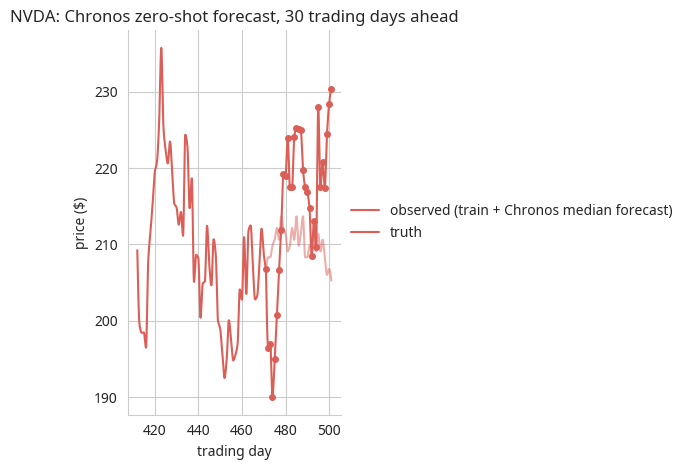

In [7]:
tk = 'NVDA'
df = datasets[tk]
price = np.exp(df['log_close'].values)
day = np.arange(len(df))
context = 60

train_tail = pd.DataFrame({'price': price[-HOLD - context:-HOLD]},
                           index=day[-HOLD - context:-HOLD])
held_out = pd.DataFrame({'price': price[-HOLD:]}, index=day[-HOLD:])

fig = hyp.plot(train_tail, ndims=1, reduce=None,
               predict={'model': 'Chronos', 'kwargs': {'model_name': 'amazon/chronos-t5-tiny'}},
               t=HOLD, truth=held_out,
               names=['observed (train + Chronos median forecast)'], legend=True,
               xlabel='trading day', ylabel='price ($)',
               title=f'{tk}: Chronos zero-shot forecast, {HOLD} trading days ahead')

## Visualizing forecasts in reduced space

`hyp.plot(..., predict=..., t=...)` overlays a forecast
tail (in the *same*, plotted space -- after HyperTools' normalize / reduce
/ align pipeline) on top of each input dataset, styled exactly like the
trace it continues -- same color, linestyle and linewidth -- at half its
opacity, so it reads as the same series projected forward. We add
log trading volume as a second feature per ticker purely so there's more
than one dimension to reduce and plot.

We fit and plot the trailing 60 trading days per ticker, smoothed at the canonical first pipeline stage with `manip={'model': 'Smooth', 'kwargs': {'kernel': 'boxcar', 'kernel_width': 11}}` -- an 11-day boxcar over both features (a boxcar width must be odd, which is why it is 11 and not 10), applied by HyperTools before normalize/reduce rather than in pandas so the 30-step forecast tails are visible at the plotted scale -- fitting on the full 2-year history makes the tails microscopic next to the cloud of training points.  Tickers whose recent prices were flat produce short, nearly stationary tails; that is the honest shape of the Kalman forecast, not a rendering artifact.

`ndims=2` reduces the (log price, log volume) pair to a 2-D plot rather than hypertools' default 3-D: with only two input features, a third component would carry no information.

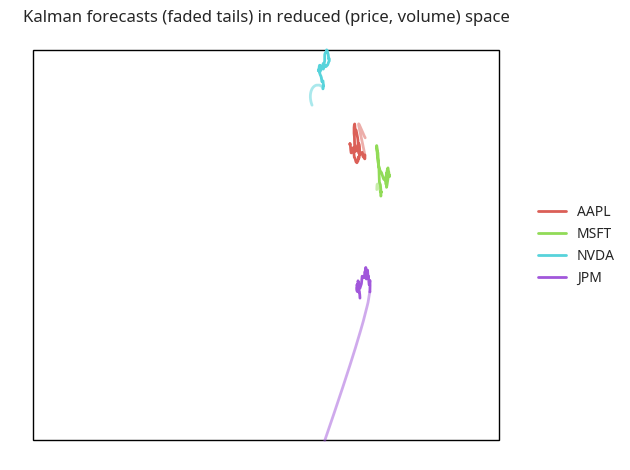

In [8]:
context = 60   # trailing trading days to fit/plot per ticker

train_2col = []
for tk in tickers:
    log_close = np.log(closes[tk].dropna())
    log_volume = np.log(volumes[tk].reindex(log_close.index)
                        .replace(0, np.nan)).ffill()
    df = pd.DataFrame({'log_close': log_close.values,
                        'log_volume': log_volume.values})
    train_2col.append(df.iloc[:-HOLD].tail(context).reset_index(drop=True))

fig = hyp.plot(train_2col, predict='Kalman', t=HOLD, legend=tickers,
               manip={'model': 'Smooth', 'kwargs': {'kernel': 'boxcar', 'kernel_width': 11}},
               ndims=2, linewidth=2,
               title='Kalman forecasts (faded tails) in reduced (price, volume) space')

## Best model vs. actual, in price space

Rather than the abstract reduced space above, let's look at the best model
(by average MAPE, chosen above -- not cherry-picked per ticker) directly in
dollar terms for each ticker: an `ndims=1` panel per ticker (the real
trading day as its index, so `hyp.plot` draws the x-axis itself) whose
`predict=`/`truth=` overlay the model's forecast and the real held-out
prices in one call -- the model is refit directly on each panel's own
trailing dollar-price series, rather than reusing the log-price backtest
forecast computed above.

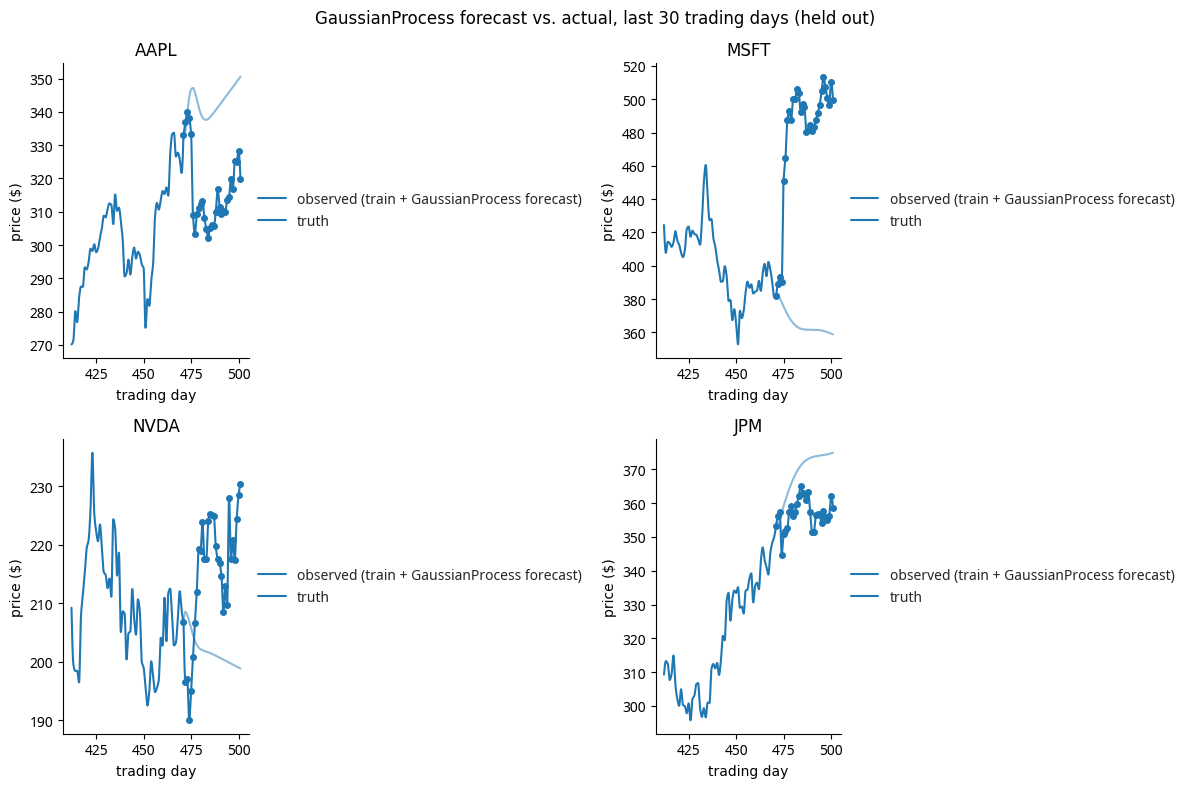

In [9]:
fig, axes = hyp.subplots(2, 2, ndims=1, size=(12, 8))
context = 60  # trailing days of history to show for context

for ax, tk in zip(axes, tickers):
    df = datasets[tk]
    price = np.exp(df['log_close'].values)
    day = np.arange(len(df))
    train_tail = pd.DataFrame({'price': price[-HOLD - context:-HOLD]},
                               index=day[-HOLD - context:-HOLD])
    held_out = pd.DataFrame({'price': price[-HOLD:]}, index=day[-HOLD:])
    # predict=/truth= fit and forecast directly on this panel's own
    # trailing dollar-price series -- no refitting from the log-price
    # backtest above, so the drawn forecast is the model applied fresh
    # to exactly what's plotted.
    hyp.plot(train_tail, reduce=None, ndims=1, predict=best_model, t=HOLD,
             truth=held_out, ax=ax, title=tk,
             names=[f'observed (train + {best_model} forecast)'],
             legend=(ax is axes[0]),
             xlabel='trading day', ylabel='price ($)',
             show=False)

fig.suptitle(f'{best_model} forecast vs. actual, last {HOLD} trading days '
             '(held out)')
fig.tight_layout()

## Reusing a fitted forecaster with `return_model=True`

`hyp.predict(..., return_model=True)` also returns the *fitted* forecaster
object. That fitted instance can be passed back in as `model=` on brand new
data, and it will apply its already-learned parameters directly -- no
re-fitting/re-estimation -- via `Forecaster.predict_new` under the hood.

To demonstrate: we pool the (log-price) training data from three tickers
(`AAPL`, `MSFT`, `NVDA`) into one combined series and fit a single
`AutoRegressor` forecaster on it. Then we hand that *already-fitted*
forecaster the fourth ticker's (`JPM`) training tail -- a stock it has
never seen -- and ask it to forecast forward. The learned lag-regression
weights are reused as-is; only `JPM`'s own recent values seed the
recursion.

In [10]:
pool_tickers = ['AAPL', 'MSFT', 'NVDA']
reuse_ticker = 'JPM'

pooled_train = pd.concat(
    [datasets[tk].iloc[:-HOLD] for tk in pool_tickers], ignore_index=True)

_, fitted_forecaster = hyp.predict(pooled_train, model='AutoRegressor',
                                    t=HOLD, return_model=True)
print('Fitted on pooled', pool_tickers, '-- is_fitted:',
      fitted_forecaster.is_fitted)

jpm_train = datasets[reuse_ticker].iloc[:-HOLD].reset_index(drop=True)
reused_forecast = hyp.predict(jpm_train, model=fitted_forecaster, t=HOLD)

jpm_actual_price = np.exp(datasets[reuse_ticker].iloc[-HOLD:]['log_close'].values)
reused_price = np.exp(reused_forecast['log_close'].values)
reused_mape = np.mean(np.abs((reused_price - jpm_actual_price) / jpm_actual_price)) * 100

# the backtest above already fit a per-ticker AutoRegressor on JPM -- reuse
# that forecast (no refitting) for an apples-to-apples, dollar-space MAPE.
jpm_own_price = np.exp(forecasts[(reuse_ticker, 'AutoRegressor')]['log_close'].values)
jpm_own_mape = np.mean(np.abs((jpm_own_price - jpm_actual_price) / jpm_actual_price)) * 100

print(f"Reused-forecaster MAPE on {reuse_ticker}: {reused_mape:.2f}%")
print(f"(for comparison, {reuse_ticker}'s own freshly-fit AutoRegressor MAPE: "
      f"{jpm_own_mape:.2f}%)")

Fitted on pooled ['AAPL', 'MSFT', 'NVDA'] -- is_fitted: True
Reused-forecaster MAPE on JPM: 3.41%
(for comparison, JPM's own freshly-fit AutoRegressor MAPE: 4.25%)


As expected for a lag-regression fit on *other* stocks' price dynamics and
then pointed at a new one, this is not a substitute for fitting directly on
the ticker you care about -- but it demonstrates the mechanics of
`return_model=True`: the forecaster's learned parameters were reused
as-is, with no re-estimation, on data it had never seen.

## Next steps

- [`hyp.predict` API reference](../api.rst) -- full parameter docs for
  every model (`'Kalman'`, `'GaussianProcess'`, `'AutoRegressor'`,
  `'ARIMA'`, `'Laplace'`, `'Chronos'`).
- `hyp.plot(..., predict=..., t=...)` overlays forecasts directly on any
  plot -- see the `plot_predict` gallery example.
- `hyp.impute` (a sibling module) fills in *missing* observations rather
  than forecasting *future* ones -- see the `projectile_kalman` tutorial
  and the `plot_impute` gallery example.
- Try a larger Chronos checkpoint (`model_name='amazon/chronos-t5-small'`
  and up -- see the [Chronos model cards](https://huggingface.co/amazon/chronos-t5-tiny))
  or pass your own scikit-learn regressor to `AutoRegressor(model=...)`.